# Models for Intermittents Series
Test models made specifically for intermittent time series (Croston, CrostonSBA and TSB).

# 0. Imports

In [1]:
# To be able to import utils' functions
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
# Utils
from utils.data_loader_utils import load_sales_data

from tqdm import tqdm

import os

import logging

# Types
from typing import List, Tuple

# Data Analysis
import pandas as pd
import numpy as np

# Models
from sktime.forecasting.croston import Croston
from sktime.forecasting.base import ForecastingHorizon
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit
from statsforecast import StatsForecast
from statsforecast.models import CrostonSBA, TSB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# 1. Load data

In [3]:
df_sales = load_sales_data(
    sales_data_path='../data/train.csv',
    add_demand_classification=True
)

df_sales = df_sales[df_sales['date'] >= '2017-04-15']

display(df_sales)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2781702,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
2781703,2017-04-15,1,BABY CARE,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
2781704,2017-04-15,1,BEAUTY,1.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781705,2017-04-15,1,BEVERAGES,1946.000,13,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2781706,2017-04-15,1,BOOKS,0.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,lumpy


In [4]:
# Get granularity with the most sales
display(
     df_sales[df_sales['demand_type'] == 'intermittent']
    .groupby(['store_nbr', 'family'])['sales']
    .sum()
    .reset_index()
    .sort_values(by='sales', ascending=False)
    .head(n=30)
)

,store_nbr,family,sales
97,18,PRODUCE,238952.5578
93,18,HOME CARE,25416.0000
138,25,HOME CARE,11652.0000
133,24,PET SUPPLIES,2168.0000
129,24,CELEBRATION,2100.0000
237,43,CELEBRATION,1880.0000
132,24,LADIESWEAR,1697.0000
123,23,LADIESWEAR,1640.0000
94,18,LADIESWEAR,1574.0000
134,24,PLAYERS AND ELECTRONICS,1367.0000


In [5]:
# Select granularity with a lot of sales
df_subset = df_sales[(df_sales['store_nbr'] == 18) & (df_sales['family'] == 'PRODUCE')].sort_values(by='date')

display(df_subset)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2782029,2017-04-15,18,PRODUCE,1627.372,5,52.905000,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2783811,2017-04-16,18,PRODUCE,2359.614,5,52.762500,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2785593,2017-04-17,18,PRODUCE,1650.644,6,52.620000,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2787375,2017-04-18,18,PRODUCE,3861.551,151,52.460000,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2789157,2017-04-19,18,PRODUCE,1529.983,6,50.490000,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992305,2017-08-11,18,PRODUCE,1297.814,7,48.810000,Quito,Pichincha,B,16,Traslado Primer Grito de Independencia,N/A,N/A,intermittent
2994087,2017-08-12,18,PRODUCE,1329.457,7,48.403333,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2995869,2017-08-13,18,PRODUCE,2095.933,7,47.996667,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent
2997651,2017-08-14,18,PRODUCE,1520.275,7,47.590000,Quito,Pichincha,B,16,N/A,N/A,N/A,intermittent


# 2. Croston

In [6]:
def plot_last_fold(df_sales: pd.DataFrame, fold_data: dict,
                    date_col: str = 'date'):
    """
    Plot results from the last fold of a cross-validation.
    
    Args:
        df_sales: Original dataframe with dates
        fold_data: Dictionary with last fold data.
        date_col: name of the date column. Defaults
            to 'date'.
    """
    
    train_idx = fold_data['train_idx']
    test_idx = fold_data['test_idx']
    
    # Get last 90 days of training for visualization
    train_plot_start = max(0, len(train_idx) - 90)
    train_plot_indices = train_idx[train_plot_start:]
    
    # Extract data
    dates_train = df_sales[date_col].iloc[train_plot_indices].values
    y_train = fold_data['y_train'].iloc[train_plot_start:].values \
        if isinstance(fold_data['y_train'], pd.Series) else fold_data['y_train']
    fitted = fold_data['fitted_values'].iloc[train_plot_start:].values \
        if isinstance(fold_data['fitted_values'], pd.Series) else fold_data['fitted_values']
    
    dates_test = df_sales[date_col].iloc[test_idx].values 
    y_test = fold_data['y_test'].values if isinstance(fold_data['y_test'], pd.Series) else fold_data['y_test']
    forecast = fold_data['forecast'].values if isinstance(fold_data['forecast'], pd.Series) else fold_data['forecast']
    
    # Create plot
    plt.figure(figsize=(14, 6))
    
    # Train data
    sns.lineplot(
        x=dates_train,
        y=y_train,
        label='Train (Real)',
        alpha=0.7,
        color='blue'
    )

    # Fitted values
    sns.lineplot(
        x=dates_train,
        y=fitted,
        label='Fitted Values',
        linestyle='--',
        color='blue',
        alpha=0.5
    )
    
    # Test data
    sns.lineplot(
        x=dates_test,
        y=y_test,
        label='Test (Real)',
        alpha=0.7,
        color='green',
        linewidth=2
    )
    
    # Forecast
    sns.lineplot(
        x=dates_test,
        y=forecast,
        label='Forecast',
        linestyle='--',
        color='red',
        linewidth=2
    )
        
    plt.title("Real vs Predicted (Last Fold)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Running 5 folds with test_size=15...

Fold 1:
  Train: 2017-04-15 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.3913
  Test RMSLE: 0.4135

Fold 2:
  Train: 2017-04-15 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.3970
  Test RMSLE: 0.3703

Fold 3:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.3898
  Test RMSLE: 0.3807

Fold 4:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.3979
  Test RMSLE: 0.3954

Fold 5:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.3857
  Test RMSLE: 0.4181

Cross-Validation Results:
   Train RMSLE Mean: 0.3924
   Train RMSLE Std:  0.0046
   Train Min RMSLE:  0.3857
   Train Max RMSLE:  0.3979
   Test RMSLE Mean: 0.3956
   Test RMSLE Std:  0.0184
   Test Min RMSLE:  0.3703
   Test Max RMSLE:  0.4181


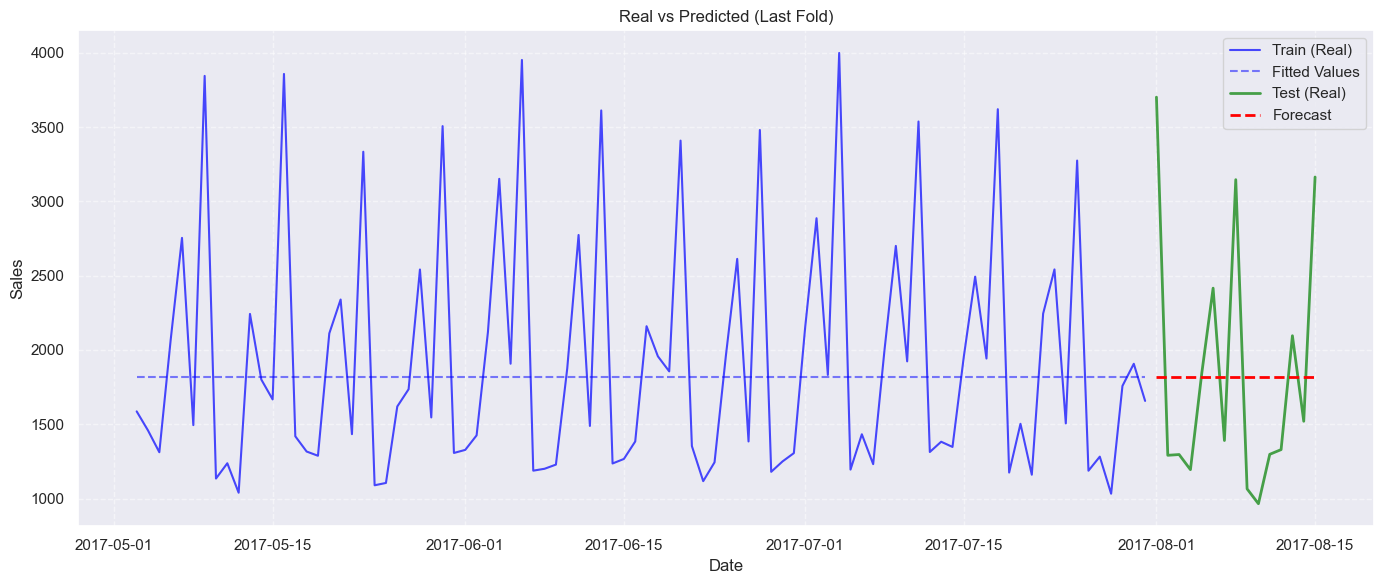

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,18,PRODUCE,0.392356,0.00457,0.385738,0.397937,0.395623,0.01839,0.370334,0.418135,238952.5578,123,intermittent,5


In [7]:
def train_and_evaluate_croston_model(df_sales: pd.DataFrame, n_splits: int = 5,
                                     test_size: int = 15, plot_results: bool = False,
                                     skew_threshold: int = None, verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a Croston model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.sort_values(by='date').copy()
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(y)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):
        # Split data
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = Croston()

        model.fit(y_train)

        # ---- FORECAST VALUES ----
        fh_out = ForecastingHorizon([i + 1 for i in range(test_size)], is_relative=True)
        test_forecast = model.predict(fh_out)

        # ---- FITTED VALUES ----
        fh_in = ForecastingHorizon(y_train.index, is_relative=False)
        fitted_values = model.predict(fh_in)

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales['date'].iloc[train_idx]
            test_dates = df_sales['date'].iloc[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if fold == tscv.get_n_splits(y):
            fh_in = ForecastingHorizon(y_train.index, is_relative=False)
            fitted_values = model.predict(fh_in)
            
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train
                
            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })


df_metrics = train_and_evaluate_croston_model(df_subset, verbose=True, plot_results=True)

display(df_metrics)

In [8]:
df_sampled = pd.read_csv('../data/experiments_results/sampled_data.csv')

df_sampled = df_sampled[df_sampled['demand_type'] == 'intermittent']

display(df_sampled)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
1,2017-04-15,10,MAGAZINES,0.0,0,52.905,Quito,Pichincha,C,15,NaN,NaN,NaN,intermittent
7,2017-04-15,14,BOOKS,0.0,0,52.905,Riobamba,Chimborazo,C,7,NaN,NaN,NaN,intermittent
10,2017-04-15,15,HOME APPLIANCES,0.0,0,52.905,Ibarra,Imbabura,C,15,NaN,NaN,NaN,intermittent
17,2017-04-15,18,PET SUPPLIES,2.0,0,52.905,Quito,Pichincha,B,16,NaN,NaN,NaN,intermittent
21,2017-04-15,21,BOOKS,0.0,0,52.905,Santo Domingo,Santo Domingo de los Tsachilas,B,6,NaN,NaN,NaN,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10914,2017-08-15,39,PET SUPPLIES,6.0,0,47.570,Cuenca,Azuay,B,6,NaN,NaN,NaN,intermittent
10918,2017-08-15,41,BABY CARE,0.0,0,47.570,Machala,El Oro,D,4,NaN,NaN,NaN,intermittent
10927,2017-08-15,47,HARDWARE,0.0,0,47.570,Quito,Pichincha,A,14,NaN,NaN,NaN,intermittent
10931,2017-08-15,48,HOME APPLIANCES,0.0,0,47.570,Quito,Pichincha,A,14,NaN,NaN,NaN,intermittent


In [9]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training croston model'):
    try:
        df_metrics = train_and_evaluate_croston_model(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_croston = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_croston.sort_values(by='test_rmsle_mean'))

Training croston model: 100%|██████████| 14/14 [00:00<00:00, 15.58it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
1,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
4,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
8,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
10,41,BABY CARE,0.085348,0.071946,0.000000,0.159755,0.150553,0.121747,0.000000,0.303856,6.0,6,intermittent,5
2,15,HOME APPLIANCES,0.253580,0.012154,0.239362,0.268775,0.281496,0.032837,0.242850,0.317351,18.0,15,intermittent,5
7,37,SCHOOL AND OFFICE SUPPLIES,0.402726,0.018789,0.376201,0.430287,0.347361,0.065667,0.277347,0.451650,42.0,35,intermittent,5
6,30,BABY CARE,0.302791,0.028053,0.257208,0.341737,0.400059,0.049504,0.316549,0.455520,36.0,28,intermittent,5
9,39,PET SUPPLIES,0.457126,0.028155,0.413580,0.496474,0.463389,0.058459,0.385737,0.566449,943.0,123,intermittent,5
0,10,MAGAZINES,0.510037,0.023636,0.481221,0.536360,0.469433,0.052397,0.377589,0.532526,81.0,56,intermittent,5
13,54,HARDWARE,0.489415,0.028448,0.448063,0.519880,0.492649,0.052662,0.400059,0.562274,84.0,56,intermittent,5


In [10]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_croston.to_csv('../data/experiments_results/croston.csv')

# df_full_metrics_croston = pd.read_csv('../data/experiments_results/croston.csv')

# 3. CrostonSBA

Running 5 folds with test_size=15...

Fold 1:
  Train: 2017-04-15 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 1.1461
  Test RMSLE: 0.4116

Fold 2:
  Train: 2017-04-15 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 1.0231
  Test RMSLE: 0.3642

Fold 3:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.9349
  Test RMSLE: 0.3895

Fold 4:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.8716
  Test RMSLE: 0.3798

Fold 5:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.8220
  Test RMSLE: 0.4121

Cross-Validation Results:
   Train RMSLE Mean: 0.9595
   Train RMSLE Std:  0.1150
   Train Min RMSLE:  0.8220
   Train Max RMSLE:  1.1461
   Test RMSLE Mean: 0.3914
   Test RMSLE Std:  0.0185
   Test Min RMSLE:  0.3642
   Test Max RMSLE:  0.4121


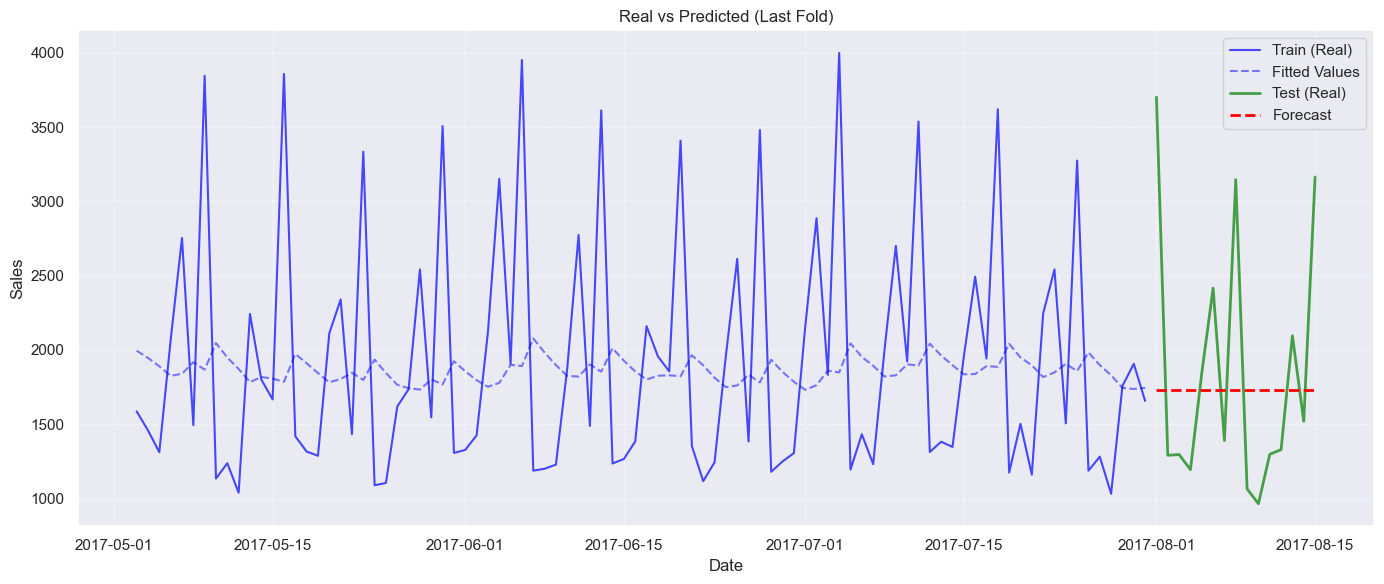

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,18,PRODUCE,0.95952,0.114967,0.821983,1.146065,0.391435,0.018529,0.364153,0.412108,238952.5578,123,intermittent,5


In [11]:
def train_and_evaluate_croston_sba_model(df_sales: pd.DataFrame, n_splits: int = 5,
                                     test_size: int = 15, plot_results: bool = False,
                                     skew_threshold: int = None, verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a CrostonSBA model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.sort_values(by='date').copy()
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    df_sales = df_sales.rename(columns={
        'date': 'ds',
        target_column: 'y'
    })

    df_sales['unique_id'] = df_sales[['store_nbr', 'family']].astype(str).agg('_'.join, axis=1)

    demand_type = df_sales['demand_type'].iloc[0]
    store_nbr = df_sales['store_nbr'].iloc[0]
    family = df_sales['family'].iloc[0]

    df_sales = df_sales[['unique_id', 'ds', 'y']]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(df_sales)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_sales), 1):
        # Split data
        df_train = df_sales.iloc[train_idx]
        y_train = df_train['y']

        df_test = df_sales.iloc[test_idx]
        y_test = df_test['y']

        model = StatsForecast(
            models=[CrostonSBA()],
            freq='D',
            n_jobs=-1
        )

        model.fit(df=df_train)

        # ---- FORECAST VALUES ----
        test_forecast = model.forecast(df=df_train, h=test_size)['CrostonSBA'].values.tolist()

        # ---- FITTED VALUES ----
        fitted_values = model.fitted_[0,0].predict_in_sample()['fitted']

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]
        fitted_values = np.nan_to_num(fitted_values, nan=0)

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales['ds'].iloc[train_idx]
            test_dates = df_sales['ds'].iloc[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if fold == tscv.get_n_splits(df_sales):
            test_forecast = model.forecast(df=df_train, h=test_size)['CrostonSBA'].values.tolist()[-90:]
            fitted_values = [val if val >= 0 else 0 for val in fitted_values][-90:]
            fitted_values = np.nan_to_num(fitted_values, nan=0)

            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train
                
            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data, date_col='ds')

        return pd.DataFrame({
            'store_nbr': store_nbr,
            'family': family,
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [demand_type],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': store_nbr,
            'family': family,
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [demand_type],
            'n_folds': [0]
        })


df_metrics = train_and_evaluate_croston_sba_model(df_subset, verbose=True, plot_results=True)

display(df_metrics)

In [12]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training croston sba model'):
    try:
        df_metrics = train_and_evaluate_croston_sba_model(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_croston_sba = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_croston_sba.sort_values(by='test_rmsle_mean'))

Training croston sba model: 100%|██████████| 14/14 [00:01<00:00, 13.10it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
1,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
4,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
8,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
10,41,BABY CARE,0.085770,0.072322,0.000000,0.160657,0.150435,0.122046,0.000000,0.304148,6.0,6,intermittent,5
2,15,HOME APPLIANCES,0.262466,0.009731,0.251393,0.277057,0.279969,0.033118,0.241242,0.316217,18.0,15,intermittent,5
7,37,SCHOOL AND OFFICE SUPPLIES,0.417902,0.019965,0.387613,0.441669,0.335933,0.066257,0.265163,0.440893,42.0,35,intermittent,5
6,30,BABY CARE,0.304249,0.027065,0.258431,0.338285,0.401151,0.050296,0.315572,0.458225,36.0,28,intermittent,5
9,39,PET SUPPLIES,0.506177,0.007422,0.496036,0.517418,0.460765,0.057598,0.390228,0.559581,943.0,123,intermittent,5
0,10,MAGAZINES,0.539629,0.017879,0.518707,0.569361,0.461437,0.053932,0.370335,0.534850,81.0,56,intermittent,5
13,54,HARDWARE,0.691682,0.052634,0.633647,0.780170,0.489265,0.054450,0.395815,0.565461,84.0,56,intermittent,5


In [13]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_croston_sba.to_csv('../data/experiments_results/croston_sba.csv')

# df_full_metrics_croston_sba = pd.read_csv('../data/experiments_results/croston_sba.csv')

# 4. TSB

Running 5 folds with test_size=15...

Fold 1:
  Train: 2017-04-15 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 1.1472
  Test RMSLE: 0.4135

Fold 2:
  Train: 2017-04-15 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 1.0248
  Test RMSLE: 0.3703

Fold 3:
  Train: 2017-04-15 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.9370
  Test RMSLE: 0.3807

Fold 4:
  Train: 2017-04-15 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.8736
  Test RMSLE: 0.3954

Fold 5:
  Train: 2017-04-15 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.8247
  Test RMSLE: 0.4181

Cross-Validation Results:
   Train RMSLE Mean: 0.9614
   Train RMSLE Std:  0.1145
   Train Min RMSLE:  0.8247
   Train Max RMSLE:  1.1472
   Test RMSLE Mean: 0.3956
   Test RMSLE Std:  0.0184
   Test Min RMSLE:  0.3703
   Test Max RMSLE:  0.4181


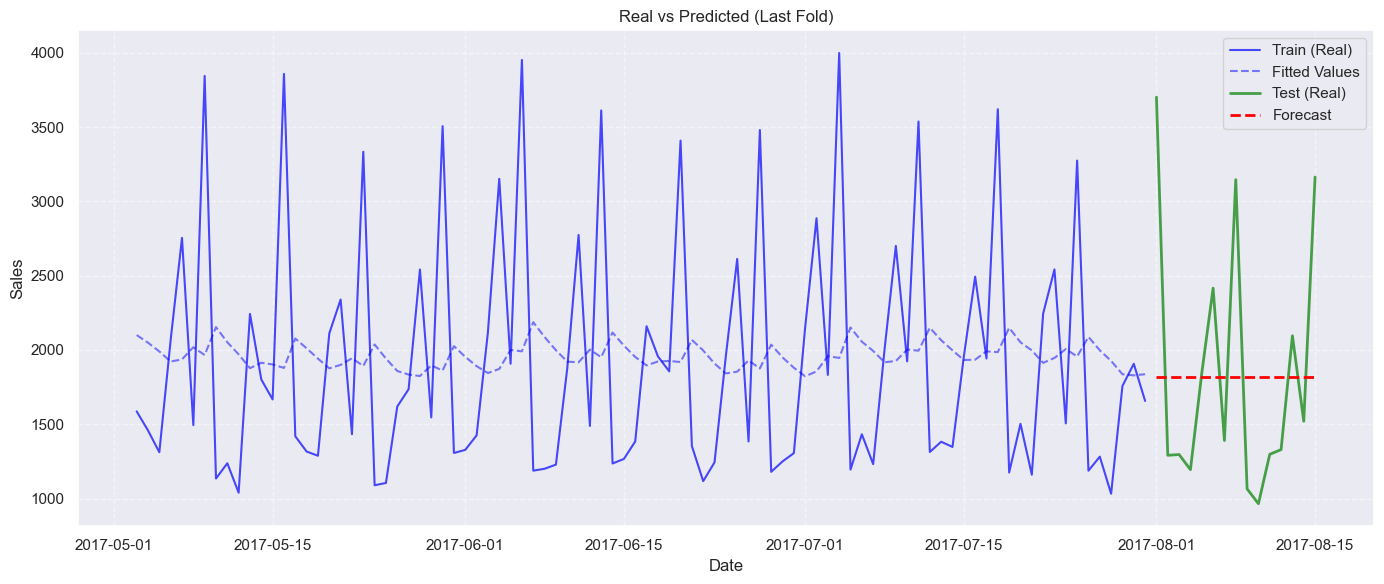

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,18,PRODUCE,0.961432,0.114494,0.824661,1.147193,0.395623,0.01839,0.370334,0.418135,238952.5578,123,intermittent,5


In [14]:
def train_and_evaluate_tsb_model(df_sales: pd.DataFrame, n_splits: int = 5,
                                     test_size: int = 15, plot_results: bool = False,
                                     skew_threshold: int = None, verbose: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a TSB model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.sort_values(by='date').copy()
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    df_sales = df_sales.rename(columns={
        'date': 'ds',
        target_column: 'y'
    })

    df_sales['unique_id'] = df_sales[['store_nbr', 'family']].astype(str).agg('_'.join, axis=1)

    demand_type = df_sales['demand_type'].iloc[0]
    store_nbr = df_sales['store_nbr'].iloc[0]
    family = df_sales['family'].iloc[0]

    df_sales = df_sales[['unique_id', 'ds', 'y']]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(df_sales)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_sales), 1):
        # Split data
        df_train = df_sales.iloc[train_idx]
        y_train = df_train['y']

        df_test = df_sales.iloc[test_idx]
        y_test = df_test['y']

        model = StatsForecast(
            models=[TSB(alpha_d=0.1, alpha_p=0.01)],
            freq='D',
            n_jobs=-1
        )

        model.fit(df=df_train)

        # ---- FORECAST VALUES ----
        test_forecast = model.forecast(df=df_train, h=test_size)['TSB'].values.tolist()

        # ---- FITTED VALUES ----
        fitted_values = model.fitted_[0,0].predict_in_sample()['fitted']

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]
        fitted_values = np.nan_to_num(fitted_values, nan=0)

        # Calculate metrics
        if 'log' in target_column:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train)

            y_test_real = np.expm1(y_test)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train

            y_test_real = y_test
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales['ds'].iloc[train_idx]
            test_dates = df_sales['ds'].iloc[test_idx]
            print(f"Fold {fold}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")

        # Store last fold data for plotting
        if fold == tscv.get_n_splits(df_sales):
            test_forecast = model.forecast(df=df_train, h=test_size)['TSB'].values.tolist()[-90:]
            fitted_values = [val if val >= 0 else 0 for val in fitted_values][-90:]
            fitted_values = np.nan_to_num(fitted_values, nan=0)

            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train
                
            last_fold_data = {
                'train_idx': train_idx,
                'test_idx': test_idx,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real,
                'y_test': y_test_real,
                'forecast': forecast_real,
            }

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data, date_col='ds')

        return pd.DataFrame({
            'store_nbr': store_nbr,
            'family': family,
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [demand_type],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': store_nbr,
            'family': family,
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [demand_type],
            'n_folds': [0]
        })


df_metrics = train_and_evaluate_tsb_model(df_subset, verbose=True, plot_results=True)

display(df_metrics)

In [15]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training TSB model'):
    try:
        df_metrics = train_and_evaluate_tsb_model(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_tsb = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_tsb.sort_values(by='test_rmsle_mean'))

Training TSB model: 100%|██████████| 14/14 [00:01<00:00, 12.85it/s]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
1,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
4,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
8,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,intermittent,5
10,41,BABY CARE,0.085353,0.071873,0.000000,0.159531,0.154709,0.116109,0.000000,0.301688,6.0,6,intermittent,5
7,37,SCHOOL AND OFFICE SUPPLIES,0.458884,0.038804,0.406130,0.515262,0.264709,0.070381,0.178699,0.378723,42.0,35,intermittent,5
2,15,HOME APPLIANCES,0.251180,0.011706,0.239444,0.268970,0.276918,0.035535,0.235626,0.318327,18.0,15,intermittent,5
6,30,BABY CARE,0.307002,0.025997,0.263117,0.340282,0.400885,0.050165,0.315504,0.458330,36.0,28,intermittent,5
0,10,MAGAZINES,0.552238,0.024973,0.520219,0.588174,0.432184,0.101677,0.340667,0.576838,81.0,56,intermittent,5
9,39,PET SUPPLIES,0.507983,0.007299,0.499991,0.519525,0.463389,0.058459,0.385737,0.566449,943.0,123,intermittent,5
3,18,PET SUPPLIES,0.641241,0.027636,0.611243,0.687023,0.559280,0.144693,0.436774,0.841903,648.0,120,intermittent,5


In [16]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_tsb.to_csv('../data/experiments_results/tsb.csv')

# df_full_metrics_tsb = pd.read_csv('../data/experiments_results/tsb.csv')

# 5. Results Analysis

In [17]:
df_full_metrics_croston = pd.read_csv('../data/experiments_results/croston.csv')
df_full_metrics_croston_sba = pd.read_csv('../data/experiments_results/croston_sba.csv')
df_full_metrics_tsb = pd.read_csv('../data/experiments_results/tsb.csv')
df_full_metrics_baseline = pd.read_csv('../data/experiments_results/baseline.csv')

df_full_metrics_croston['Model'] = 'Croston'
df_full_metrics_croston_sba['Model'] = 'CrostonSBA'
df_full_metrics_tsb['Model'] = 'TSB'
df_full_metrics_baseline['Model'] = 'Baseline'

df_metrics = pd.concat([df_full_metrics_croston, df_full_metrics_croston_sba, df_full_metrics_tsb, df_full_metrics_baseline],
                            ignore_index=True)
df_metrics = df_metrics.drop(df_metrics.columns[0], axis=1)

display(df_metrics)

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds,Model
0,10,MAGAZINES,0.510037,0.023636,0.481221,0.536360,0.469433,0.052397,0.377589,0.532526,81.00000,56,intermittent,5,Croston
1,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,5,Croston
2,15,HOME APPLIANCES,0.253580,0.012154,0.239362,0.268775,0.281496,0.032837,0.242850,0.317351,18.00000,15,intermittent,5,Croston
3,18,PET SUPPLIES,0.578245,0.027124,0.554073,0.629495,0.552868,0.146487,0.438750,0.842376,648.00000,120,intermittent,5,Croston
4,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,intermittent,5,Croston
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,52,CELEBRATION,0.820283,0.064523,0.755243,0.922259,0.576839,0.151596,0.361503,0.775478,1343.00000,117,smooth,5,Baseline
127,52,SCHOOL AND OFFICE SUPPLIES,1.658375,0.288052,1.312480,2.021427,0.788471,0.225583,0.460817,1.122046,2232.00000,113,erratic,5,Baseline
128,53,FROZEN FOODS,0.702009,0.199869,0.461935,0.907199,0.699821,0.213371,0.450498,1.010648,18175.84501,123,erratic,5,Baseline
129,54,HARDWARE,0.611736,0.127704,0.534839,0.865729,0.607735,0.110687,0.506203,0.768020,84.00000,56,intermittent,5,Baseline


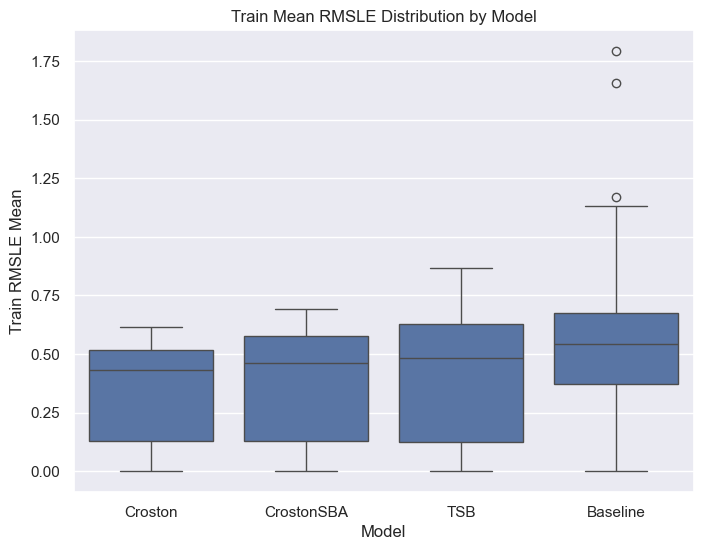

Croston mean: 0.3420
CrostonSBA mean: 0.3723
TSB mean: 0.3993
Baseline mean: 0.5462


In [18]:
# Train set mean

plt.rcParams['figure.figsize'] = (8, 6)

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

croston_train_mean = df_full_metrics_croston['train_rmsle_mean'].mean()
croston_sba_train_mean = df_full_metrics_croston_sba['train_rmsle_mean'].mean()
tsb_train_mean = df_full_metrics_tsb['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline['train_rmsle_mean'].mean()

print(f"Croston mean: {croston_train_mean:.4f}")
print(f"CrostonSBA mean: {croston_sba_train_mean:.4f}")
print(f"TSB mean: {tsb_train_mean:.4f}")
print(f"Baseline mean: {baseline_train_mean:.4f}")

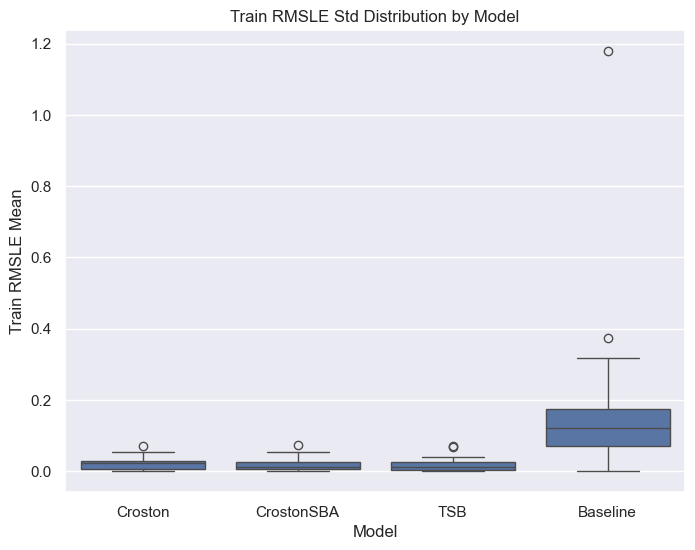

Croston mean: 0.0229
CrostonSBA mean: 0.0187
TSB mean: 0.0218
Baseline mean: 0.1401


In [19]:
# Train set std

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


croston_train_std_mean = df_full_metrics_croston['train_rmsle_std'].mean()
croston_sba_train_std_mean = df_full_metrics_croston_sba['train_rmsle_std'].mean()
tsb_train_std_mean = df_full_metrics_tsb['train_rmsle_std'].mean()
baseline_train_std_mean = df_full_metrics_baseline['train_rmsle_std'].mean()

print(f"Croston mean: {croston_train_std_mean:.4f}")
print(f"CrostonSBA mean: {croston_sba_train_std_mean:.4f}")
print(f"TSB mean: {tsb_train_std_mean:.4f}")
print(f"Baseline mean: {baseline_train_std_mean:.4f}")

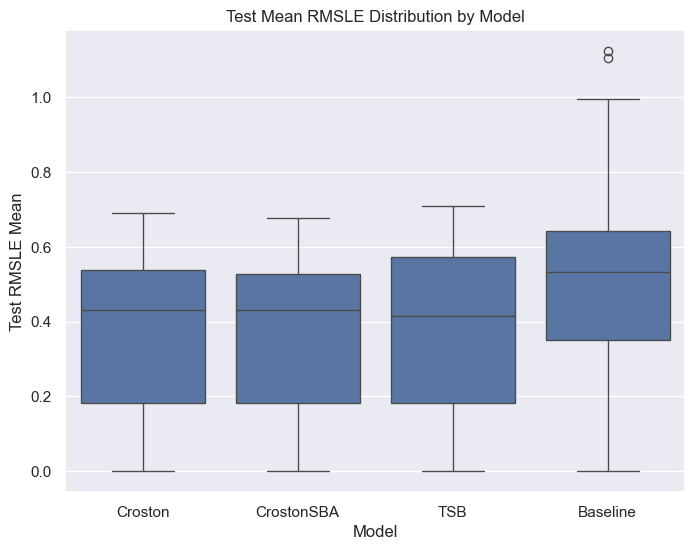

Croston mean: 0.3567
CrostonSBA mean: 0.3516
TSB mean: 0.3640
Baseline mean: 0.5124


In [20]:
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

croston_test_mean = df_full_metrics_croston['test_rmsle_mean'].mean()
croston_sba_test_mean = df_full_metrics_croston_sba['test_rmsle_mean'].mean()
tsb_test_mean = df_full_metrics_tsb['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline['test_rmsle_mean'].mean()

print(f"Croston mean: {croston_test_mean:.4f}")
print(f"CrostonSBA mean: {croston_sba_test_mean:.4f}")
print(f"TSB mean: {tsb_test_mean:.4f}")
print(f"Baseline mean: {baseline_test_mean:.4f}")

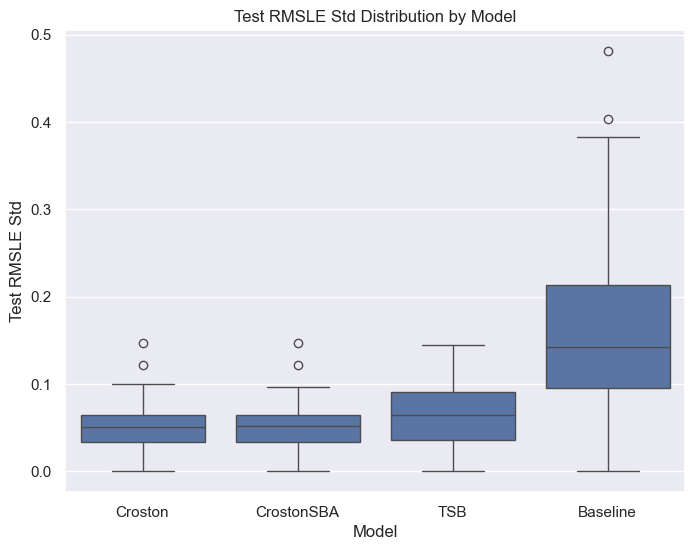

Croston mean: 0.0545
CrostonSBA mean: 0.0542
TSB mean: 0.0611
Baseline mean: 0.1592


In [21]:
# Test set std
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

croston_test_std = df_full_metrics_croston['test_rmsle_std'].mean()
croston_sba_test_std = df_full_metrics_croston_sba['test_rmsle_std'].mean()
tsb_test_std = df_full_metrics_tsb['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline['test_rmsle_std'].mean()

print(f"Croston mean: {croston_test_std:.4f}")
print(f"CrostonSBA mean: {croston_sba_test_std:.4f}")
print(f"TSB mean: {tsb_test_std:.4f}")
print(f"Baseline mean: {baseline_test_std:.4f}")

Croston got better results for the training set and CrostonSBA better ones for the test set. Therefore, we are choosing CrostonSBA as the best model for intermittent series.